In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
from matplotlib import pyplot as plt
import torch

from tqdm.notebook import tqdm, trange

from main import *
from data import *

params = {
      'text.usetex': True,
      'font.family': 'sans serif'
}
matplotlib.rcParams.update(params)

## Load data

In [179]:
grayscale = False
train_loader, test_loader, info = load_data("CIFAR10", grayscale=grayscale)
images = next(iter(train_loader))  # warmup

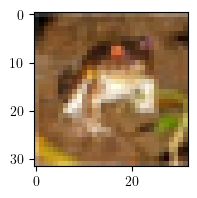

In [180]:
from PIL import Image

def show_image(image, title=None):
    if grayscale == False:
        image = image.permute(1, 2, 0).numpy()
        image = (image * 255).astype(np.uint8)
    else:  
        image = image.squeeze().numpy()
        image = (image * 255).astype(np.uint8)
    img = Image.fromarray(image)
    # Show in the jupyter notebook, and custom size
    plt.figure(figsize=(2, 2))
    plt.imshow(img)

show_image(images[0][0], title="Sample Image from CIFAR10")

## Covariance matrix -- Random

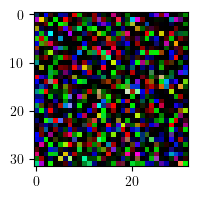

In [ ]:
# Sample 32 x 32 x 3 random samples where each sample phi_i is such that log phi_i is uniformly distributed in log t_min, log t_max
t_min = 1E-9 #t_min is
t_max = 1E3
repeat_channel = False

if grayscale == False:
    if repeat_channel == False:
        num_samples = 32 * 32 * 3
        log_phi_samples = np.random.uniform(np.log(t_min), np.log(t_max), num_samples)
        phi_samples = np.exp(log_phi_samples)
        # Define a random subset of r pixels, set the value to 1
        # r = int(num_samples * 0.2)
        # indices = np.random.choice(num_samples, r, replace=False)
        # phi_samples[indices] = 1.0
        # Reshape to 3 x 32 x 32
        phi_samples = torch.tensor(phi_samples, dtype=torch.float32).view(3, 32, 32)
    else:
        num_samples = 32 * 32
        log_phi_samples = np.random.uniform(np.log10(t_min), np.log10(t_max), num_samples)
        # print("log_phi_samples", log_phi_samples)
        phi_samples = np.exp(log_phi_samples)
        # Define a random subset of r pixels, set the value to 1
        r = int(num_samples * 1.0)
        indices = np.random.choice(num_samples, r, replace=False)
        phi_samples[indices] = 1.0
        # Reshape to 3 x 32 x 32
        phi_samples = torch.tensor(phi_samples, dtype=torch.float32).view(32, 32).unsqueeze(0).repeat(3, 1, 1)
else:
    num_samples = 32 * 32
    log_phi_samples = np.random.uniform(np.log(t_min), np.log(t_max), num_samples)
    phi_samples = np.exp(log_phi_samples)
    # For half of the vector, set the value to 1
    phi_samples[:num_samples // 2] = 1.0
    # Reshape to 32 x 32 x 3
    phi_samples = torch.tensor(phi_samples, dtype=torch.float32).view(1, 32, 32)

show_image(phi_samples, title="Sampled Phi Values")

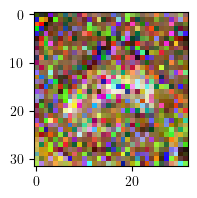

In [187]:
sigma_noise = 1
image = images[0][0].view(-1)

cov = torch.diag(phi_samples.view(-1))  # Covariance matrix

sqrt_cov = np.sqrt(cov)

y_noisy = image + sigma_noise * sqrt_cov @ np.random.randn(*image.shape)
# Reshape back to 32 x 32 x 3
if grayscale == False:
    y_noisy = y_noisy.view(3, 32, 32)
else:
    y_noisy = y_noisy.view(1, 32, 32)
show_image(y_noisy, title="Masked Image with Random Samples")

In [186]:
B, C, H, W = images[0].shape
D = C * H * W

# Step 1: Sample standard Gaussian noise: shape (B, D)
standard_noise = torch.randn(B, D)

# Step 2: Apply sqrt_cov (D, D) to each sample in the batch
colored_noise = sigma_noise * (standard_noise @ sqrt_cov.T)  # shape: (B, D)

# Step 3: Add noise
colored_noise = colored_noise.view(B, C, H, W)  # Reshape to (B, C, H, W)
noisy_images = images[0] + colored_noise # Shape: (B, C, H, W)

# Step 4: Compute MSE 
# Case norm 2
noise = (noisy_images - images[0]).view(B, -1)
c_noise = noise @ torch.linalg.inv(torch.tensor(cov)).T
diff_dsm = (noisy_images.view(B, -1) - c_noise)
# Placeholder of E[x|y] is noisy_images
mse = torch.mean((noisy_images - c_noise.view(B, C, H , W)) ** 2, dim=(-1, -2, -3))
mse_2 = torch.einsum('bi,ij,bj->b', diff_dsm, torch.eye(D), diff_dsm) / D # Divide by D to compute the mean over pixels and channels
print(mse, mse_2)

# Case norm given by the cov matrix
mse = torch.einsum('bi,ij,bj->b', diff_dsm, torch.tensor(cov), diff_dsm) / D
print(mse)
# mse = torch.mean(quadratic_form_dsm, dim=(-1, -2, -3))


/tmp/ipykernel_655241/4294619310.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  c_noise = noise @ torch.linalg.inv(torch.tensor(cov)).T


tensor([37718332., 34845488., 37277924., 33319160., 35410604., 34443500.,
        48595904., 35998492., 35322524., 40385972., 38537492., 36973212.,
        37121204., 42949052., 32850232., 38044092., 39358400., 40151396.,
        39777872., 43007124., 34165884., 32750688., 36628200., 33331398.,
        36363360., 40372396., 33060314., 36205508., 32306634., 38023772.,
        35720060., 37008624., 32928554., 36957100., 40418704., 36133792.,
        33018320., 30033280., 31264130., 49755952., 32899006., 36574852.,
        33027744., 32940486., 38540752., 36065564., 36591744., 40512012.,
        34765260., 38472776., 34340276., 32942190., 34000008., 34390396.,
        39251924., 40752816., 36483512., 36758500., 32521504., 33584540.,
        40089124., 40526100., 39799096., 35913464., 38320292., 34844660.,
        32257598., 37737660., 37828724., 37156964., 35607252., 38094888.,
        33789764., 32993878., 38284520., 40599948., 42907540., 36332756.,
        32114264., 38248628., 37746552

/tmp/ipykernel_655241/4294619310.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mse = torch.einsum('bi,ij,bj->b', diff_dsm, torch.tensor(cov), diff_dsm) / D


## Covariance matrix -- from H

In [ ]:
# Utility functions

def build_sampling_matrix(known_indices, total_pixels):
    """
    Builds a sampling matrix M from a list of known pixel indices.

    Args:
        known_indices (list or np.array): 1D indices of the known/observed pixels.
                                         These should be unique and sorted for consistency,
                                         though the function will work with unsorted unique indices.
        total_pixels (int): Total number of pixels in the original image (N).

    Returns:
        np.ndarray: The sampling matrix M (K x N), where K is the number of known pixels.
    """
    # Ensure known_indices are unique, as duplicate rows in M don't make sense
    # for this type of sampling matrix.
    unique_known_indices = np.unique(known_indices)
    num_known_pixels = len(unique_known_indices)

    M = np.zeros((num_known_pixels, total_pixels))
    for i, idx in enumerate(unique_known_indices): # Iterate over sorted unique indices
        if 0 <= idx < total_pixels:
            M[i, idx] = 1.0
        else:
            # This check might be redundant if known_indices are generated correctly,
            # but good for robustness.
            raise ValueError(f"Index {idx} is out of bounds for total_pixels {total_pixels}")
    return M


def get_reconstruction_operator_G(M):
    """
    Computes the reconstruction operator G using the Moore-Penrose pseudoinverse.
    G = M^T (M M^T)^-1

    Args:
        M (np.ndarray): The sampling matrix (K x N).

    Returns:
        np.ndarray: The reconstruction operator G (N x K).
    """
    MMT = M @ M.T
    try:
        MMT_inv = np.linalg.inv(MMT)
    except np.linalg.LinAlgError:
        print("MM^T is singular. Using pseudoinverse for (MM^T)^-1 instead.")
        MMT_inv = np.linalg.pinv(MMT) # Use pseudoinverse if MMT is singular
                                      # (e.g. if M has dependent rows)
    G = M.T @ MMT_inv
    return G

def build_reconstructed_noise_covariance(M, sigma_sq):
    """
    Builds the covariance matrix of noise in the reconstructed image.
    Assumes observation noise covariance C_Nobs = sigma_sq * I.
    Uses G = M^T (M M^T)^-1. So C_N_X_hat = sigma_sq * G @ G.T

    Args:
        M (np.ndarray): The sampling matrix (K x N).
        sigma_sq (float): Variance of the white observation noise.

    Returns:
        np.ndarray: The covariance matrix C_N_X_hat (N x N).
    """
    G = get_reconstruction_operator_G(M)
    C_N_X_hat = sigma_sq * (G @ G.T)
    return C_N_X_hat

def build_reconstructed_noise_covariance_direct(M, sigma_sq):
    """
    Builds the covariance matrix of noise in the reconstructed image directly.
    Formula: C_N_X_hat = sigma_sq * M.T @ ( (M M^T)^-2 ) @ M

    Args:
        M (np.ndarray): The sampling matrix (K x N).
        sigma_sq (float): Variance of the white observation noise.

    Returns:
        np.ndarray: The covariance matrix C_N_X_hat (N x N).
    """
    MMT = M @ M.T
    try:
        MMT_inv = np.linalg.inv(MMT)
    except np.linalg.LinAlgError:
        print("MM^T is singular. Using pseudoinverse for (MM^T)^-1 for MMT_inv_sq.")
        # If MMT is singular, MMT_inv_sq will also be problematic.
        # np.linalg.matrix_power might handle pinv result better or fail.
        # This direct formula is more sensitive to singularity of MMT.
        MMT_inv = np.linalg.pinv(MMT)

    MMT_inv_sq = np.linalg.matrix_power(MMT_inv, 2) # (MM^T)^-2
    C_N_X_hat = sigma_sq * (M.T @ MMT_inv_sq @ M)
    return C_N_X_hat

In [ ]:
# # Image dimensions
# h, w, c = images[0][0].shape
# total_pixels_N = h * w * c

# # Percentage of known pixels
# percentage_known = 0.5 # 10%
# num_known_pixels_K = int(total_pixels_N * percentage_known)

# sigma_noise = 1 # Variance of observation noise

# print(f"Image dimensions: {h}x{w}x{c}")
# print(f"Total number of pixels (N): {total_pixels_N}")
# print(f"Percentage of known pixels: {percentage_known*100}%")
# print(f"Number of known pixels (K): {num_known_pixels_K}")

# # Generate random unique indices for the known pixels
# # np.random.choice ensures uniqueness if replace=False
# if num_known_pixels_K > total_pixels_N:
#     raise ValueError("Number of known pixels cannot exceed total pixels.")

# # Generate all possible indices
# all_possible_indices = np.arange(total_pixels_N)
# # Randomly choose K unique indices from all possible indices
# random_known_indices = np.random.choice(all_possible_indices, size=num_known_pixels_K, replace=False)
# # Sorting is good practice for consistency if you ever need to compare M matrices
# # generated with the same set of random indices but in a different order.
# random_known_indices.sort()

# # 1. Build the sampling matrix M
# try:
#     M_sampling = build_sampling_matrix(random_known_indices, total_pixels_N)
#     print(f"\nSuccessfully built Sampling Matrix M.")
#     print(f"Shape of M (K x N): {M_sampling.shape}")


# except ValueError as e:
#     print(f"Error building sampling matrix: {e}")
# except Exception as e:
#     print(f"An unexpected error occurred: {e}")

# # 2. Build the reconstructed noise covariance matrix C_N_X_hat
# # Using the G G^T formulation (generally more stable if MMT_inv needs pinv)
# # cov = build_reconstructed_noise_covariance(M_sampling, sigma_noise)
# sqrt_cov = np.linalg.pinv(M_sampling.T @ M_sampling) @ M_sampling.T
# print("\nCovariance of Noise in Reconstructed Image (C_N_X_hat) (N x N) using G G.T:\n", cov)

# image = images[0][0].view(-1)
# sigma_noise = 1e-3
# y_noisy = image + sigma_noise * cov @ np.random.randn(*image.shape)
# # Reshape back to 32 x 32 x 3
# if grayscale == False:
#     y_noisy = y_noisy.view(3, 32, 32)
# else:
#     y_noisy = y_noisy.view(1, 32, 32)
# show_image(y_noisy, title="Masked Image with Random Samples")


[0.10313599 0.14021526 0.17012277 ... 0.05737627 0.38471147 0.07431749]


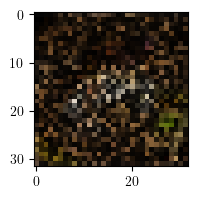

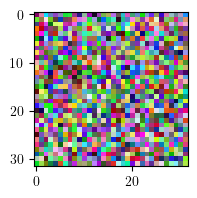

In [104]:
sigma_noise = 1
image = images[0][0].view(-1)

log_H = np.random.uniform(np.log10(1e-3), np.log10(1e0), int(image.shape[0] / 3))
H = np.exp(log_H)

print(H)
# Repeat H for each channel if grayscale is False
if grayscale == False:
    H = np.tile(H, 3)
else:
    H = np.random.randint(0, 2, size = image.shape)

# Mask image. First, vectorize the image, then multiply by phi_samples
masked_image = torch.tensor(np.diag(H)).float() @ image
# Reshape back to 32 x 32 x 3
if grayscale == False:
    masked_image = masked_image.view(3, 32, 32)
else:
    masked_image = masked_image.view(1, 32, 32)
show_image(masked_image, title="Masked Image with H")

### Generate noisy image using cov matrix ###

# Define a diagonal covariance matrix with the sampled phi values
sqrt_cov = np.sqrt(1 / H)
sqrt_cov = np.diag(sqrt_cov)
sqrt_cov[sqrt_cov == np.inf] = 1e6  # Handle inf values

y_noisy = image + sigma_noise * sqrt_cov @ np.random.randn(*image.shape)

# Reshape back to 32 x 32 x 3
if grayscale == False:
    y_noisy = y_noisy.view(3, 32, 32)
else:
    y_noisy = y_noisy.view(1, 32, 32)
show_image(y_noisy, title="Noisy Image")

## Testing dimensions of losses

In [ ]:
B, C, H, W = images[0].shape
D = C * H * W

# Step 1: Sample standard Gaussian noise: shape (B, D)
standard_noise = torch.randn(B, D)

# Step 2: Apply sqrt_cov (D, D) to each sample in the batch
colored_noise = sigma_noise * (standard_noise @ sqrt_cov.T)  # shape: (B, D)

# Step 3: Add noise
colored_noise = colored_noise.view(B, C, H, W)  # Reshape to (B, C, H, W)
noisy_images = images[0] + colored_noise # Shape: (B, C, H, W)


In [ ]:
# Step 4: Compute MSE 

# Case norm 2
noise = (noisy_images - images[0]).view(B, -1)
c_noise = noise @ torch.linalg.inv(torch.tensor(cov)).T
diff_dsm = (noisy_images.view(B, -1) - c_noise)
# Placeholder of E[x|y] is noisy_images
mse = torch.mean((noisy_images - c_noise.view(B, C, H , W)) ** 2, dim=(-1, -2, -3))
mse_2 = torch.einsum('bi,ij,bj->b', diff_dsm, torch.eye(D).double(), diff_dsm) / D # Divide by D to compute the mean over pixels and channels
print(mse, mse_2)

# Case norm given by the cov matrix
mse = torch.einsum('bi,ij,bj->b', diff_dsm, torch.tensor(cov), diff_dsm) / D
print(mse)
# mse = torch.mean(quadratic_form_dsm, dim=(-1, -2, -3))

tensor([328.9270, 332.9446, 350.8743, 318.6159, 324.6812, 347.9799, 327.0730,
        345.3540, 306.1607, 331.3267, 333.8747, 348.5760, 301.3498, 347.3786,
        308.3525, 364.2049, 311.1194, 344.7456, 333.5421, 331.0642, 326.3147,
        347.1674, 307.6197, 346.6366, 389.0816, 339.8894, 368.3485, 381.2004,
        321.0393, 331.1255, 342.9160, 336.1558, 348.8317, 340.0161, 353.8863,
        340.3039, 351.0625, 325.0154, 359.8674, 334.8764, 321.9303, 294.4550,
        327.0796, 363.9091, 339.6735, 307.6272, 351.5764, 360.6583, 365.9874,
        336.4574, 349.7984, 394.4407, 325.4026, 320.6821, 348.2320, 328.6175,
        330.7726, 396.6485, 330.2708, 330.2811, 329.4959, 322.6934, 330.3737,
        316.3780, 316.4742, 330.1039, 322.9053, 324.8814, 345.4480, 324.2797,
        324.8513, 326.7568, 353.6917, 344.3296, 316.2067, 339.5831, 375.1099,
        332.9659, 383.5082, 304.5171, 345.4511, 328.3772, 352.5843, 350.4462,
        349.4358, 323.4794, 326.5144, 326.8132, 327.6694, 363.25

## Deblurring

In [83]:
class H_functions:
    """
    A class replacing the SVD of a matrix H, perhaps efficiently.
    All input vectors are of shape (Batch, ...).
    All output vectors are of shape (Batch, DataDimension).
    """

    def V(self, vec):
        """
        Multiplies the input vector by V
        """
        raise NotImplementedError()

    def Vt(self, vec):
        """
        Multiplies the input vector by V transposed
        """
        raise NotImplementedError()

    def U(self, vec):
        """
        Multiplies the input vector by U
        """
        raise NotImplementedError()

    def Ut(self, vec):
        """
        Multiplies the input vector by U transposed
        """
        raise NotImplementedError()

    def singulars(self):
        """
        Returns a vector containing the singular values. The shape of the vector should be the same as the smaller dimension (like U)
        """
        raise NotImplementedError()

    def add_zeros(self, vec):
        """
        Adds trailing zeros to turn a vector from the small dimension (U) to the big dimension (V)
        """
        raise NotImplementedError()
    
    def H(self, vec):
        """
        Multiplies the input vector by H
        """
        temp = self.Vt(vec)
        singulars = self.singulars()
        return self.U(singulars * temp[:, :singulars.shape[0]])
    
    def Ht(self, vec):
        """
        Multiplies the input vector by H transposed
        """
        temp = self.Ut(vec)
        singulars = self.singulars()
        return self.V(self.add_zeros(singulars * temp[:, :singulars.shape[0]]))
    
    def H_pinv(self, vec):
        """
        Multiplies the input vector by the pseudo inverse of H
        """
        temp = self.Ut(vec)
        singulars = self.singulars()
        temp[:, :singulars.shape[0]] = temp[:, :singulars.shape[0]] / singulars
        return self.V(self.add_zeros(temp))
    
class Deblurring(H_functions):
    def mat_by_img(self, M, v):
        return torch.matmul(M, v.reshape(v.shape[0] * self.channels, self.img_dim,
                        self.img_dim)).reshape(v.shape[0], self.channels, M.shape[0], self.img_dim)

    def img_by_mat(self, v, M):
        return torch.matmul(v.reshape(v.shape[0] * self.channels, self.img_dim,
                        self.img_dim), M).reshape(v.shape[0], self.channels, self.img_dim, M.shape[1])

    def __init__(self, kernel, channels, img_dim, device, ZERO = 3e-2):
        self.img_dim = img_dim
        self.channels = channels
        #build 1D conv matrix
        self.H_vec = torch.zeros(img_dim, img_dim, device=device)
        for i in range(img_dim):
            for j in range(i - kernel.shape[0]//2, i + kernel.shape[0]//2):
                if j < 0 or j >= img_dim: continue
                self.H_vec[i, j] = kernel[j - i + kernel.shape[0]//2]
        #get the svd of the 1D conv
        self.U_small, self.singulars_small, self.V_small = torch.svd(self.H_vec, some=False)
        #ZERO = 3e-2
        self.singulars_small[self.singulars_small < ZERO] = 0
        #calculate the singular values of the big matrix
        self._singulars = torch.matmul(self.singulars_small.reshape(img_dim, 1), self.singulars_small.reshape(1, img_dim)).reshape(img_dim**2)
        #sort the big matrix singulars and save the permutation
        self._singulars, self._perm = self._singulars.sort(descending=True) #, stable=True)

    def V(self, vec):
        #invert the permutation
        temp = torch.zeros(vec.shape[0], self.img_dim**2, self.channels, device=vec.device)
        temp[:, self._perm, :] = vec.clone().reshape(vec.shape[0], self.img_dim**2, self.channels)
        temp = temp.permute(0, 2, 1)
        #multiply the image by V from the left and by V^T from the right
        out = self.mat_by_img(self.V_small, temp)
        out = self.img_by_mat(out, self.V_small.transpose(0, 1)).reshape(vec.shape[0], -1)
        return out

    def Vt(self, vec):
        #multiply the image by V^T from the left and by V from the right
        temp = self.mat_by_img(self.V_small.transpose(0, 1), vec.clone())
        temp = self.img_by_mat(temp, self.V_small).reshape(vec.shape[0], self.channels, -1)
        #permute the entries according to the singular values
        temp = temp[:, :, self._perm].permute(0, 2, 1)
        return temp.reshape(vec.shape[0], -1)

    def U(self, vec):
        #invert the permutation
        temp = torch.zeros(vec.shape[0], self.img_dim**2, self.channels, device=vec.device)
        temp[:, self._perm, :] = vec.clone().reshape(vec.shape[0], self.img_dim**2, self.channels)
        temp = temp.permute(0, 2, 1)
        #multiply the image by U from the left and by U^T from the right
        out = self.mat_by_img(self.U_small, temp)
        out = self.img_by_mat(out, self.U_small.transpose(0, 1)).reshape(vec.shape[0], -1)
        return out

    def Ut(self, vec):
        #multiply the image by U^T from the left and by U from the right
        temp = self.mat_by_img(self.U_small.transpose(0, 1), vec.clone())
        temp = self.img_by_mat(temp, self.U_small).reshape(vec.shape[0], self.channels, -1)
        #permute the entries according to the singular values
        temp = temp[:, :, self._perm].permute(0, 2, 1)
        return temp.reshape(vec.shape[0], -1)

    def singulars(self):
        return self._singulars.repeat(1, 3).reshape(-1)

    def add_zeros(self, vec):
        return vec.clone().reshape(vec.shape[0], -1)
    
    def get_H(self):
        """
        Multiplies the input vector by H
        """
        return self.H_vec 

channels = 3
img_size = 32
H_deblur = Deblurring(torch.Tensor([1/9] * 9), channels, img_size, device=torch.device("cpu"))